In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Crop_recommendation.csv")
df.info()
print(df.head())
# print(df.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [3]:
mlflow.set_experiment("Crop Recommendation")

df.columns=df.columns.str.strip()
X=df.drop('label',axis=1)
y=df["label"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y,shuffle=True)


In [4]:
print(df.columns)

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')


In [5]:
scaler=StandardScaler()
X_train_s=scaler.fit_transform(X_train)
X_test_s=scaler.transform(X_test)

2026/04/06 20:35:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 20:35:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


0.9840909090909091
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 19  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  1  0  0 19  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  

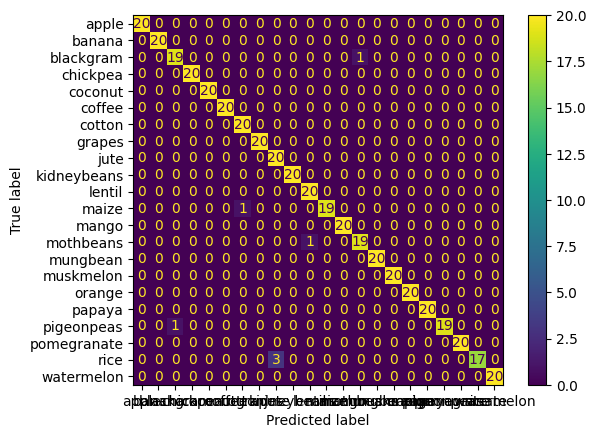

In [ ]:
# training logistic regression model without scaling
from sklearn.linear_model import LogisticRegression
with mlflow.start_run(run_name="Logistic regression"):
    lrm=LogisticRegression(max_iter=100000)
    lrm.fit(X_train,y_train)

    y_pred=lrm.predict(X_test)

    acc=accuracy_score(y_test,y_pred)
    clas=classification_report(y_test,y_pred)
    disp = ConfusionMatrixDisplay.from_estimator(lrm, X_test, y_test)
    plt.savefig("confusion_matrix.png")
    mlflow.log_artifact("confusion_matrix.png")
    mlflow.log_param("model_type","logistic regression")
    mlflow.log_metric("accuracy",acc)
    with open("metric.txt","w") as f:
        f.write(clas)
        # f.write(con)
    mlflow.log_artifact("metric.txt")
    mlflow.sklearn.log_model(lrm,"model")
runs=mlflow.search_runs(experiment_names=["Crop Recommendation"])
best_run=runs.sort_values("metrics.accuracy", ascending=False).iloc[0]
print(f"{acc}\n{con}\n{clas}")

In [7]:
# training logistic regression model with scaling
lrm=LogisticRegression(max_iter=100000)
lrm.fit(X_train_s,y_train)

y_pred=lrm.predict(X_test_s)

acc=accuracy_score(y_test,y_pred)
con=confusion_matrix(y_test,y_pred)
clas=classification_report(y_test,y_pred)
print(f"{acc}\n{con}\n{clas}")

0.9727272727272728
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0 17  0  0  2  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  1  0  1 18  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  

In [8]:
# training knn model with scaling

from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier(n_neighbors=7,metric="manhattan")
knn.fit(X_train_s,y_train)

y_pred=knn.predict(X_test_s)

acc=accuracy_score(y_test,y_pred)
con=confusion_matrix(y_test,y_pred)
clas=classification_report(y_test,y_pred)
print(f"{acc}\n{con}\n{clas}")

0.9795454545454545
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0  1  0  1 17  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  

In [9]:
# training decision tree model without scaling

from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(random_state=42,criterion='gini',max_depth=10)
dt.fit(X_train,y_train)
y_pred=dt.predict(X_test)

acc=accuracy_score(y_test,y_pred)
con=confusion_matrix(y_test,y_pred)
clas=classification_report(y_test,y_pred)
print(f"{acc}\n{con}\n{clas}")


0.9636363636363636
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 18  0  0  0  0  0  0  0  0  1  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 18  0  0  2  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  8  0  0 12  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  1  0  0 19  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  

In [10]:
# training decision tree model without scaling

dt=DecisionTreeClassifier(random_state=42,criterion='entropy',max_depth=6)
dt.fit(X_train,y_train)
y_pred=dt.predict(X_test)

acc=accuracy_score(y_test,y_pred)
con=confusion_matrix(y_test,y_pred)
clas=classification_report(y_test,y_pred)
print(f"{acc}\n{con}\n{clas}")


0.9681818181818181
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 16  0  0  0  0  0  0  0  0  1  0  3  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  6  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  

In [11]:
# training svm model with scaling
from sklearn.svm import SVC

svc=SVC(kernel='rbf',gamma='scale',C=2,max_iter=3000)
svc.fit(X_train_s,y_train)
y_pred=svc.predict(X_test_s)

acc=accuracy_score(y_test,y_pred)
con=confusion_matrix(y_test,y_pred)
clas=classification_report(y_test,y_pred)
print(f"{acc}\n{con}\n{clas}")


0.9863636363636363
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 19  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  2  0  0  0  0 18  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  1 19  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  

In [12]:
# training random forest model without scaling

from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=1000,criterion='entropy',max_depth=15,max_leaf_nodes=10,class_weight='balanced')
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)

acc=accuracy_score(y_test,y_pred)
con=confusion_matrix(y_test,y_pred)
clas=classification_report(y_test,y_pred)
print(f"{acc}\n{con}\n{clas}")

0.9409090909090909
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 19  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 20  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0  2  0  0 17  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_c

In [13]:
# final observations.........

# Multiple machine learning models were trained and evaluated for crop prediction using soil and environmental features. The dataset being balanced and well-structured allowed most models to achieve high accuracy.

# Logistic Regression and SVM achieved the highest accuracy (~98%+), indicating that the dataset is highly separable. KNN also performed well but showed slight sensitivity to overlapping feature distributions.

# Decision Tree models achieved slightly lower accuracy and showed tendencies of overfitting due to their hierarchical nature. After tuning, minor improvements were observed.

# Random Forest performance improved after tuning but initially underperformed due to improper preprocessing and parameter selection. After correction, it provided stable performance and is useful for feature importance extraction.

# The strong performance of simpler models such as Logistic Regression suggests that the dataset is well-structured and linearly separable. This reduces the need for highly complex models and indicates that soil and environmental features are highly predictive of crop type.

# Overall, the dataset characteristics favor linear and kernel-based models, as the decision boundaries between crop classes are well-defined.

In [14]:
# MODEL COMPARISON INSIGHTS
# - Logistic Regression performed exceptionally well, indicating strong linear separability.
# - SVM matched or slightly outperformed Logistic Regression, capturing complex boundaries effectively.
# - KNN performed well but is sensitive to feature scaling and overlapping regions.
# - Decision Tree showed slight overfitting tendencies but is interpretable.
# - Random Forest improved after tuning and provides robust feature importance insights.

In [15]:
# BEST MODEL FOR PREDICTION

#  SVM (Primary Choice)
#  Logistic Regression (Backup / Alternative)
# SVM was selected as the final prediction model due to its high accuracy and ability to capture complex decision boundaries effectively. Logistic Regression is also a strong alternative due to its simplicity and comparable performance.

In [16]:
# BEST MODEL FOR FEATURE IMPORTANCE

# RANDOM FOREST
# Random Forest was selected for feature importance analysis due to its ability to rank features based on their contribution to predictions. This helps in understanding which environmental factors influence crop selection the most.